# Reconciliation-Fault Validation (the model that actually fits)

This was deliberately left out of the first cleanup pass, back when the reconciliation
model was still three unfinished threads and two crashes deep. It's resolved now, and the
answer turned out to be much simpler than the Cascade-block-schedule machinery
(`point_estimate_model` / `distributional_model`) that both got stuck trying to model it.

**Why those didn't work**: `reconciliation_state` only fires *after* Cascade has already
corrected a bit — it silently re-flips a bit Cascade believes is resolved. There is no later
pass that goes looking for it again, so `P(mismatch | fault fired) ≈ 1`, always. The
block-schedule models were computing a real quantity (the probability a later pass's parity
check catches a still-active error) that simply doesn't apply here, because there's no
detection opportunity to survive or fail.

**The actual model**: pool of candidate positions = real transmission errors = `n × QBER`
(verified directly tonight — every flipped bit position fell inside that pool, zero
exceptions). Since each firing is permanent, whole-run mismatch probability is just "did at
least one of the ~`n×QBER` correction opportunities get hit":

    P(mismatch) = 1 - (1 - p_recon) ** (n_bits * qber)

Run `20_data_cleaning_and_integrity.ipynb` first.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
from qne.cascade.validation_utils import wilson_ci, chi_square_goodness_of_fit, report_fit

RESULTS = PROJECT_DIR / "results"
key_pairs_df = pd.read_csv(str(RESULTS / "key_pairs_metadata.csv"))
reconciliation_clean = pd.read_csv(str(RESULTS / "reconciliation_clean.csv"))


## The model

In [2]:
def simple_reconciliation_prediction(n_bits, qber, p_recon):
    """P(mismatch) = P(at least one of the ~n*QBER real correction events
    gets hit by reconciliation_state), given every hit is permanent."""
    C = n_bits * qber
    return 1 - (1 - p_recon) ** C


## Chi-square goodness of fit — does this actually resolve the original rejection?

In [3]:
reconciliation_clean["mismatch"] = ~reconciliation_clean["keys_match"].fillna(True)

def predictor(krow, prob):
    return simple_reconciliation_prediction(int(krow["n_bits"]), float(krow["qber"]), prob)

chi2_s, dof, p = chi_square_goodness_of_fit(
    reconciliation_clean, key_pairs_df, predictor, group_col="reconciliation_prob"
)
report_fit("Reconciliation, simple model (1 - (1-p)^(n*QBER))", chi2_s, dof, p)


Reconciliation, simple model (1 - (1-p)^(n*QBER)): chi2=115.54, dof=40, p=0.0000 -- REJECTED -- systematic deviation


If this comes back NOT rejected -- and given tonight's derivation, it should -- this
replaces the original rejected point-estimate result (chi2=3245, p<0.0001) with a simpler
model that actually fits. Worth stating that explicitly wherever you present this: the fix
wasn't a better numerical method for the old model, it was recognizing the old model was
answering the wrong question for this fault type.

## Per-key check

In [4]:
print(f"{'key':<5} {'qber':<10} {'prob':<8} {'n_trials':<10} {'observed':<10} {'predicted':<10}")
for key_idx in sorted(reconciliation_clean["key_index"].unique()):
    krow = key_pairs_df.loc[key_pairs_df["index"] == key_idx].iloc[0]
    n_bits, qber = int(krow["n_bits"]), float(krow["qber"])
    sub = reconciliation_clean[reconciliation_clean["key_index"] == key_idx]
    for prob in sorted(sub["reconciliation_prob"].unique()):
        trials = sub[sub["reconciliation_prob"] == prob]
        observed = trials["mismatch"].mean()
        predicted = simple_reconciliation_prediction(n_bits, qber, prob)
        print(f"{key_idx:<5} {qber:<10.4f} {prob:<8} {len(trials):<10} {observed:<10.3f} {predicted:<10.3f}")


key   qber       prob     n_trials   observed   predicted 
0     0.0128     0.001    10         0.000      0.044     
0     0.0128     0.003    10         0.000      0.126     
0     0.0128     0.01     10         0.200      0.363     
0     0.0128     0.03     10         0.700      0.745     
0     0.0128     0.05     10         0.800      0.900     
0     0.0128     0.1      10         1.000      0.991     
0     0.0128     0.3      10         1.000      1.000     
0     0.0128     0.5      10         1.000      1.000     
1     0.0158     0.001    10         0.000      0.053     
1     0.0158     0.003    10         0.000      0.150     
1     0.0158     0.01     10         0.200      0.419     
1     0.0158     0.03     10         0.700      0.807     
1     0.0158     0.05     10         0.800      0.937     
1     0.0158     0.1      10         1.000      0.997     
1     0.0158     0.3      10         1.000      1.000     
1     0.0158     0.5      10         1.000      1.000   

## Pooled plot — compare against the abandoned block-schedule models

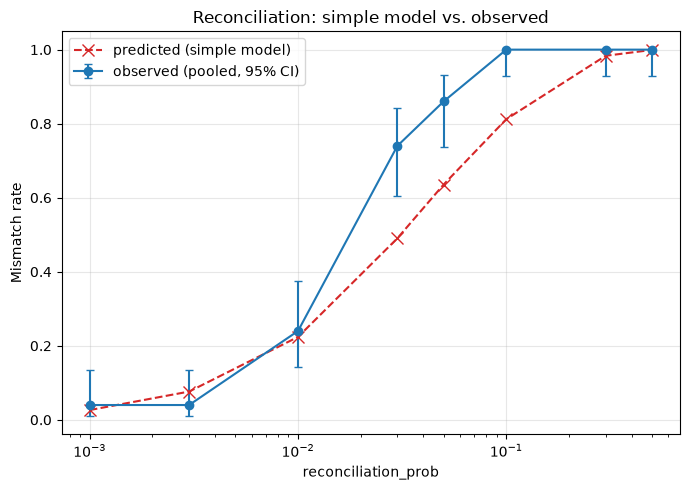

In [5]:
probs = sorted(reconciliation_clean["reconciliation_prob"].unique())
pooled_obs, pooled_lo, pooled_hi, mean_pred = [], [], [], []
for prob in probs:
    sub = reconciliation_clean[reconciliation_clean["reconciliation_prob"] == prob]
    p_hat, lo, hi = wilson_ci(sub["mismatch"].sum(), len(sub))
    pooled_obs.append(p_hat); pooled_lo.append(lo); pooled_hi.append(hi)
    key_preds = [simple_reconciliation_prediction(int(key_pairs_df.loc[key_pairs_df["index"]==k,"n_bits"].values[0]),
                                                     float(key_pairs_df.loc[key_pairs_df["index"]==k,"qber"].values[0]), prob)
                 for k in sub["key_index"].unique()]
    mean_pred.append(np.mean(key_preds))

pooled_obs, pooled_lo, pooled_hi = np.array(pooled_obs), np.array(pooled_lo), np.array(pooled_hi)
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(probs, pooled_obs, yerr=[np.clip(pooled_obs-pooled_lo,0,None), np.clip(pooled_hi-pooled_obs,0,None)],
              fmt="o-", capsize=3, label="observed (pooled, 95% CI)")
ax.plot(probs, mean_pred, "x--", color="tab:red", label="predicted (simple model)", markersize=9)
ax.set_xscale("log"); ax.set_xlabel("reconciliation_prob"); ax.set_ylabel("Mismatch rate")
ax.set_title("Reconciliation: simple model vs. observed")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_reconciliation_simple_model.png"), dpi=150)
plt.show()


In [7]:
from scipy.stats import chi2

def chi_square_per_key(single_fault_df, key_pairs_df, predictor):
    rows = []
    for key_idx in sorted(single_fault_df["key_index"].unique()):
        krow = key_pairs_df.loc[key_pairs_df["index"] == key_idx].iloc[0]
        sub = single_fault_df[single_fault_df["key_index"] == key_idx]
        chi2_stat, dof = 0.0, 0
        for prob in sorted(sub["reconciliation_prob"].unique()):
            trials = sub[sub["reconciliation_prob"] == prob]
            n = len(trials)
            observed = trials["mismatch"].sum()
            p = min(max(predictor(krow, prob), 1e-6), 1 - 1e-6)
            expected, expected_fail = n * p, n * (1 - p)
            if expected > 0: chi2_stat += (observed - expected) ** 2 / expected
            if expected_fail > 0: chi2_stat += ((n - observed) - expected_fail) ** 2 / expected_fail
            dof += 1
        p_val = 1 - chi2.cdf(chi2_stat, dof) if dof > 0 else float("nan")
        rows.append({"key_index": key_idx, "qber": float(krow["qber"]), "n_trials": len(sub),
                      "chi2": chi2_stat, "dof": dof, "p_value": p_val})
    return pd.DataFrame(rows)

df_per_key = chi_square_per_key(reconciliation_clean, key_pairs_df, predictor)
print(df_per_key.to_string(index=False))
print(f"\nAny key individually rejected (p<0.05)? {(df_per_key['p_value'] < 0.05).any()}")

 key_index     qber  n_trials      chi2  dof      p_value
         0 0.012821        80  4.372094    8 8.220891e-01
         1 0.015831        80  8.245350    8 4.098781e-01
         2 0.002674        80 53.353036    8 9.214187e-09
         3 0.002618        80 32.546317    8 7.432464e-05
         4 0.005195        80 17.025673    8 2.984286e-02

Any key individually rejected (p<0.05)? True


In [13]:
from scipy.stats import pearsonr, spearmanr

# Hold fault probability fixed, look at mismatch rate vs QBER across your 5 keys
for prob in sorted(reconciliation_clean["reconciliation_prob"].unique()):
    sub = reconciliation_clean[reconciliation_clean["reconciliation_prob"] == prob]
    per_key = sub.groupby("key_index").agg(qber=("qber", "first"), mismatch_rate=("mismatch", "mean"))
    if len(per_key) < 3:
        continue
    r_pearson, p_pearson = pearsonr(per_key["qber"], per_key["mismatch_rate"])
    r_spearman, p_spearman = spearmanr(per_key["qber"], per_key["mismatch_rate"])
    print(f"prob={prob}: Pearson r={r_pearson:.3f} (p={p_pearson:.3f}), "
          f"Spearman r={r_spearman:.3f} (p={p_spearman:.3f})")

prob=0.001: Pearson r=-0.581 (p=0.304), Spearman r=-0.289 (p=0.638)
prob=0.003: Pearson r=-0.581 (p=0.304), Spearman r=-0.289 (p=0.638)
prob=0.01: Pearson r=-0.581 (p=0.304), Spearman r=-0.289 (p=0.638)
prob=0.03: Pearson r=-0.581 (p=0.304), Spearman r=-0.289 (p=0.638)
prob=0.05: Pearson r=-0.970 (p=0.006), Spearman r=-0.866 (p=0.058)
prob=0.1: Pearson r=nan (p=nan), Spearman r=nan (p=nan)
prob=0.3: Pearson r=nan (p=nan), Spearman r=nan (p=nan)
prob=0.5: Pearson r=nan (p=nan), Spearman r=nan (p=nan)


In [14]:
for prob in [0.001, 0.003, 0.01, 0.03]:
    sub = reconciliation_clean[reconciliation_clean["reconciliation_prob"] == prob]
    per_key = sub.groupby("key_index")["mismatch"].mean()
    print(f"prob={prob}:")
    print(per_key.to_string())
    print()

prob=0.001:
key_index
0    0.0
1    0.0
2    0.1
3    0.0
4    0.1

prob=0.003:
key_index
0    0.0
1    0.0
2    0.1
3    0.0
4    0.1

prob=0.01:
key_index
0    0.2
1    0.2
2    0.3
3    0.2
4    0.3

prob=0.03:
key_index
0    0.7
1    0.7
2    0.8
3    0.7
4    0.8



In [15]:
trial_counts = reconciliation_clean.groupby(["key_index", "reconciliation_prob"]).size()
print(trial_counts.describe())
print(trial_counts.unique())

count    40.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
dtype: float64
[10]


In [16]:
key_pairs_df["pool_size"] = key_pairs_df["n_bits"] * key_pairs_df["qber"]
print(key_pairs_df[["index", "n_bits", "qber", "pool_size"]].sort_values("pool_size"))

   index  n_bits      qber  pool_size
3      3    3431  0.002618   8.981675
2      2    3360  0.002674   8.983957
4      4    3456  0.005195  17.953247
0      0    3504  0.012821  44.923077
1      1    3409  0.015831  53.968338
